In [13]:
import math, random, time
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import imageio.v2 as imageio

import gymnasium as gym

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [14]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def moving_average(x, window=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return x
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[window:] - c[:-window]) / window

def make_env(seed=0, render_mode=None):
    env = gym.make("LunarLander-v3", render_mode=render_mode)
    obs, info = env.reset(seed=seed)
    env.action_space.seed(seed)
    return env

In [15]:
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return s, a, r.astype(np.float32), s2, d.astype(np.float32)

    def __len__(self):
        return len(self.buf)

In [16]:
class QNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)

In [17]:
@torch.no_grad()
def select_action(q_net, obs, eps, n_actions):
    if random.random() < eps:
        return random.randrange(n_actions)
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    q = q_net(obs_t)
    return int(torch.argmax(q, dim=1).item())

## Core: training step (DQN vs Double DQN)

### Key difference:

- DQN target: max_a Q_target(s', a)

- Double DQN target: Q_target(s', argmax_a Q_online(s', a))

In [18]:
def train_step(
    q_online, q_target, optimizer, buffer,
    batch_size=64, gamma=0.99, double_dqn=False,
    grad_clip=10.0
):
    if len(buffer) < batch_size:
        return None

    s, a, r, s2, done = buffer.sample(batch_size)

    s_t  = torch.tensor(s,  dtype=torch.float32, device=DEVICE)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=DEVICE)
    r_t  = torch.tensor(r,  dtype=torch.float32, device=DEVICE)
    s2_t = torch.tensor(s2, dtype=torch.float32, device=DEVICE)
    d_t  = torch.tensor(done, dtype=torch.float32, device=DEVICE)

    q_sa = q_online(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        if not double_dqn:
            # DQN: action selection + evaluation both from target net
            max_next = q_target(s2_t).max(dim=1)[0]
        else:
            # Double DQN: selection from online, evaluation from target
            a_star = torch.argmax(q_online(s2_t), dim=1)
            max_next = q_target(s2_t).gather(1, a_star.unsqueeze(1)).squeeze(1)

        target = r_t + gamma * (1.0 - d_t) * max_next

    loss = nn.functional.mse_loss(q_sa, target)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    if grad_clip is not None:
        nn.utils.clip_grad_norm_(q_online.parameters(), grad_clip)
    optimizer.step()

    return float(loss.item())

- For DQN, selection and eval are same net ⇒ tends to be larger.

- For Double DQN, selection uses online and eval uses target ⇒ tends to be smaller.

In [19]:
@torch.no_grad()
def bias_metrics(q_online, q_target, states_batch):
    s_t = torch.tensor(states_batch, dtype=torch.float32, device=DEVICE)
    q_on  = q_online(s_t)
    q_tgt = q_target(s_t)

    # A) average max-Q on online net
    mean_maxQ_online = float(q_on.max(dim=1)[0].mean().item())

    # B) approximate overestimation gap:
    # max over target minus target evaluated at online-argmax
    max_tgt = q_tgt.max(dim=1)[0]
    a_star = torch.argmax(q_on, dim=1)
    eval_tgt_on_astar = q_tgt.gather(1, a_star.unsqueeze(1)).squeeze(1)
    gap = float((max_tgt - eval_tgt_on_astar).mean().item())

    return mean_maxQ_online, gap

In [20]:
def train_agent(
    algo_name="DQN",
    seed=0,
    total_steps=500_000,
    start_learning=5_000,
    batch_size=64,
    buffer_size=100_000,
    gamma=0.99,
    lr=5e-4,
    hidden=256,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay_steps=200_000,
    target_update_every=1_000,
    train_every=4,
    double_dqn=False
):
    set_seed(seed)
    env = make_env(seed=seed, render_mode=None)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    q_online = QNet(obs_dim, n_actions, hidden=hidden).to(DEVICE)
    q_target = QNet(obs_dim, n_actions, hidden=hidden).to(DEVICE)
    q_target.load_state_dict(q_online.state_dict())
    q_target.eval()

    optimizer = optim.Adam(q_online.parameters(), lr=lr)
    buffer = ReplayBuffer(capacity=buffer_size)

    # logs
    episode_returns = []
    episode_lengths = []
    losses = []
    eps_log = []

    # bias logs (sampled periodically)
    mean_maxQ_log = []
    gap_log = []
    step_log = []

    obs, info = env.reset()
    ep_return = 0.0
    ep_len = 0

    for step in range(1, total_steps + 1):
        # linear epsilon decay
        frac = min(1.0, step / max(1, eps_decay_steps))
        eps = eps_start + frac * (eps_end - eps_start)
        eps_log.append(eps)

        # act
        a = select_action(q_online, obs, eps, n_actions)
        obs2, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        buffer.push(obs, a, r, obs2, done)

        obs = obs2
        ep_return += r
        ep_len += 1

        # learn
        if step >= start_learning and step % train_every == 0:
            loss = train_step(
                q_online, q_target, optimizer, buffer,
                batch_size=batch_size, gamma=gamma, double_dqn=double_dqn
            )
            if loss is not None:
                losses.append(loss)

        # target update
        if step % target_update_every == 0:
            q_target.load_state_dict(q_online.state_dict())

        # bias probe every N steps (use random states from replay)
        if step % 5_000 == 0 and len(buffer) >= 5_000:
            # sample a batch of states for diagnostics
            s_batch, *_ = buffer.sample(512)
            mean_maxQ, gap = bias_metrics(q_online, q_target, s_batch)
            mean_maxQ_log.append(mean_maxQ)
            gap_log.append(gap)
            step_log.append(step)

        # episode end
        if done:
            episode_returns.append(ep_return)
            episode_lengths.append(ep_len)
            
            # Print progress every 50 episodes
            if len(episode_returns) % 50 == 0:
                avg_return = np.mean(episode_returns[-50:])
                print(f"[{algo_name}] Episode {len(episode_returns)}, Step {step}, Avg Return (last 50): {avg_return:.1f}, Eps: {eps:.3f}")

            obs, info = env.reset()
            ep_return = 0.0
            ep_len = 0

    env.close()

    return {
        "name": algo_name,
        "q_online": q_online,
        "q_target": q_target,
        "episode_returns": np.array(episode_returns, dtype=np.float32),
        "episode_lengths": np.array(episode_lengths, dtype=np.int32),
        "losses": np.array(losses, dtype=np.float32),
        "eps": np.array(eps_log, dtype=np.float32),
        "bias_steps": np.array(step_log, dtype=np.int32),
        "mean_maxQ": np.array(mean_maxQ_log, dtype=np.float32),
        "gap": np.array(gap_log, dtype=np.float32),
    }

In [9]:
dqn = train_agent(
    algo_name="DQN",
    seed=0,
    total_steps=500_000,
    start_learning=5_000,
    batch_size=64,
    lr=5e-4,
    hidden=256,
    eps_decay_steps=200_000,
    target_update_every=1_000,
    train_every=4,
    double_dqn=False
)

ddqn = train_agent(
    algo_name="Double DQN",
    seed=1,
    total_steps=500_000,
    start_learning=5_000,
    batch_size=64,
    lr=5e-4,
    hidden=256,
    eps_decay_steps=200_000,
    target_update_every=1_000,
    train_every=4,
    double_dqn=True
)

[Double DQN] Episode 2250, Step 492542, Avg Return (last 50): 231.1, Eps: 0.010


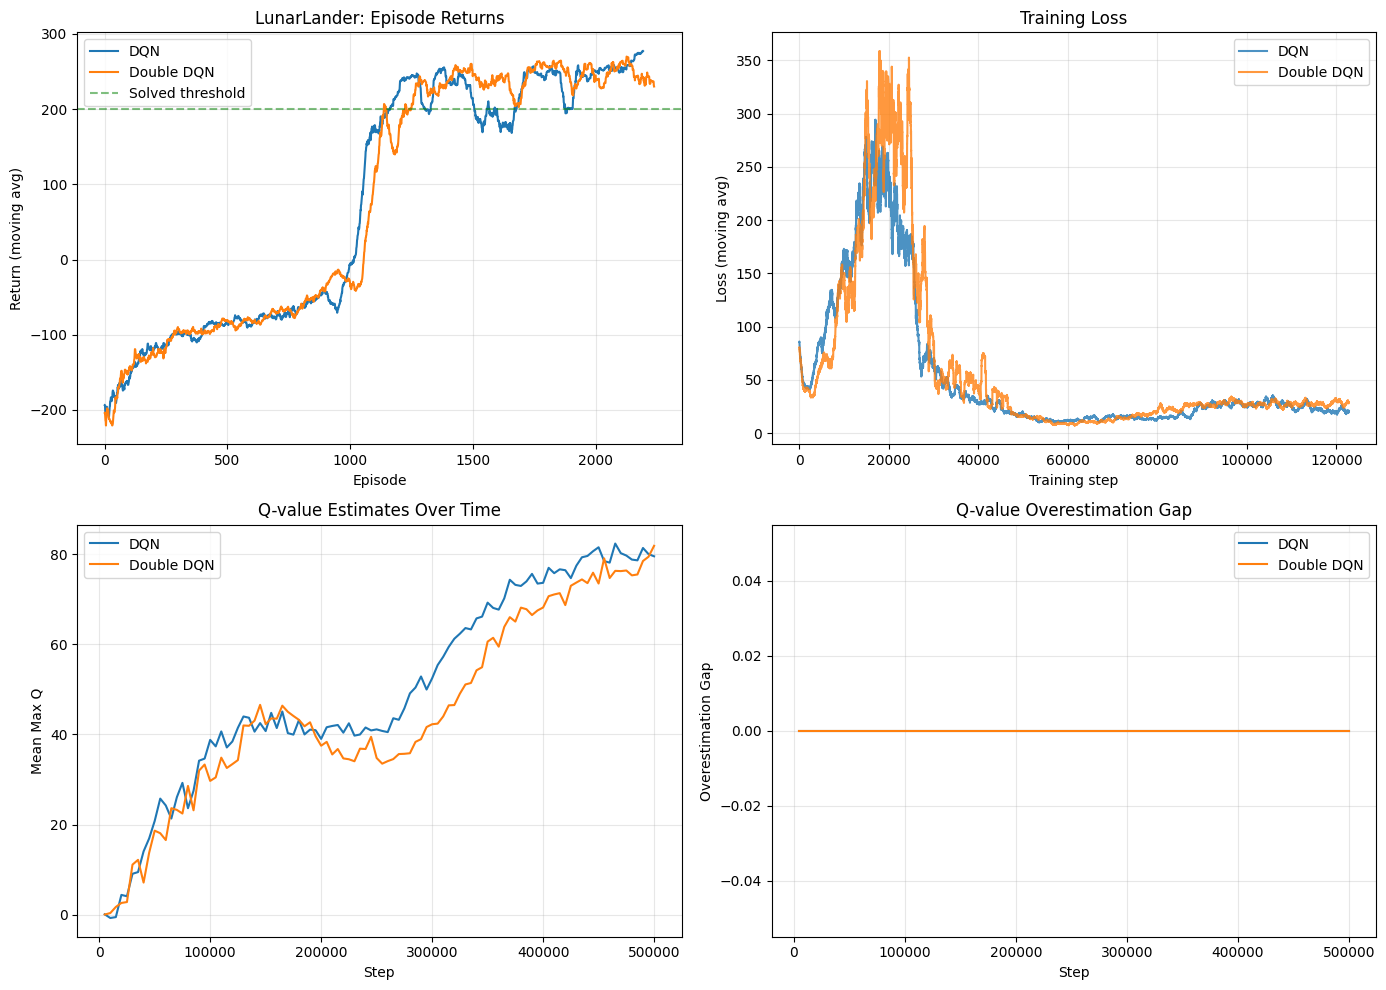

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Episode Returns
ax = axes[0, 0]
for res in [dqn, ddqn]:
    ax.plot(moving_average(res["episode_returns"], 50), label=res["name"])
ax.set_xlabel("Episode")
ax.set_ylabel("Return (moving avg)")
ax.set_title("LunarLander: Episode Returns")
ax.axhline(y=200, color='g', linestyle='--', alpha=0.5, label='Solved threshold')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss
ax = axes[0, 1]
for res in [dqn, ddqn]:
    ax.plot(moving_average(res["losses"], 1000), label=res["name"], alpha=0.8)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss (moving avg)")
ax.set_title("Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# Mean Max Q
ax = axes[1, 0]
for res in [dqn, ddqn]:
    ax.plot(res["bias_steps"], res["mean_maxQ"], label=res["name"])
ax.set_xlabel("Step")
ax.set_ylabel("Mean Max Q")
ax.set_title("Q-value Estimates Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

# Overestimation Gap
ax = axes[1, 1]
for res in [dqn, ddqn]:
    ax.plot(res["bias_steps"], res["gap"], label=res["name"])
ax.set_xlabel("Step")
ax.set_ylabel("Overestimation Gap")
ax.set_title("Q-value Overestimation Gap")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lunarlander_training.png", dpi=150)
plt.show()

In [11]:
def record_gif(q_net, filename, seed=42, max_steps=1000):
    env = make_env(seed=seed, render_mode="rgb_array")
    obs, info = env.reset()
    frames = []
    total_reward = 0
    
    for _ in range(max_steps):
        frames.append(env.render())
        a = select_action(q_net, obs, eps=0.0, n_actions=env.action_space.n)
        obs, r, terminated, truncated, info = env.step(a)
        total_reward += r
        if terminated or truncated:
            break
    
    env.close()
    imageio.mimsave(filename, frames, fps=30)
    print(f"Saved {filename} with total reward: {total_reward:.1f}")

record_gif(dqn["q_online"], "dqn_lunarlander.gif")
record_gif(ddqn["q_online"], "ddqn_lunarlander.gif")

Saved ddqn_lunarlander.gif with total reward: 267.4


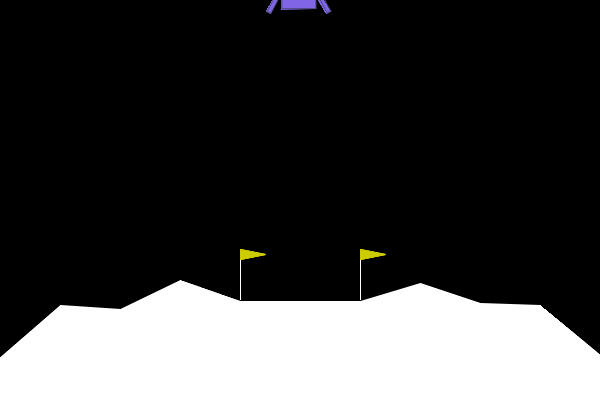

In [21]:
from IPython.display import Image, display
print("DQN Agent:")
display(Image(filename="dqn_lunarlander.gif"))
print("\nDouble DQN Agent:")
display(Image(filename="ddqn_lunarlander.gif"))